In [ ]:
# Tissue Spatial Geometrics Lab | David H. Nguyen, PhD

# Purpose: This script thresholds for red colors and creates a mask
# Note: This script is formatted for Jupyter Notebook, not Pycharm.

# Instructions: 
# 1. Set the working directory in Part 0A.2 by pasting in the file path in "os.chdir("_____")"
# 2. This working directory should only contain image files. 
# 3. The part of each image that you wanted to create a mask for should be in red color.

# Expected output:
#    For each input file, this script outputs one file with the following suffix in its name: "_mask.png"



In [1]:
##########################################################################################
##########################################################################################
# Part 0A - Load dependencies and set the working directory

import cv2
import numpy as np
import scipy.ndimage
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import colors

In [2]:
# Part 0A.2 - Set the working directory
import os
os.chdir('/Users/davidnguyen/Downloads/Test Images for Color Extraction_TEST')

path = os.getcwd() # this gets the file path of the working diretory 
contents = os.listdir(path) # this creates a list of all the files within the working directory
contents # This prints the contents of the working directory


['TEST MRI SLICE GREEN.png',
 'TEST from Windows PC RED.png',
 'TEST MRI SLICE_RED from Mac.png',
 'TEST MRI SLICE PINK.png',
 'TEST MRI SLICE BLUE.png']

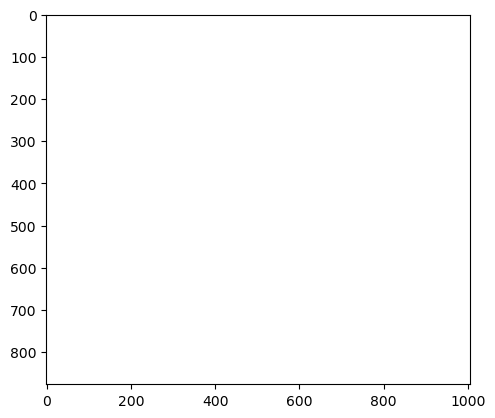

In [4]:
for item in contents:

    if item.startswith(".") == True:
        pass
    
    else:
        ##########################################################################################
        ##########################################################################################
        # Part 1A.1: Load the image and copy its name as a string for use in renaming output files

        ########
        # this function copies the name of the file that is passed into and returns that name
        def name_copier(y):
            fileName = y
            return(fileName)

        # This function returns TWO values. This function loads an image's name into cv2.imread, which is stored as "the_im",
        # and then passes that name to be returned as a string that is stored as "theName"
        def img_loader(x):
            img = f'cv2.imread("{x}")'
            nombre = name_copier(x)
            return eval(img), nombre
        ########

        # Part 1A.2: Load the image and copy its name
        the_im, theName = img_loader(item)
        #plt.imshow(the_im)
        #print(theName)

        #create a copy of the image
        img_copy = the_im.copy()
        #plt.imshow(img_copy)

        # convert to RGB (openCV loads as BGR)
        img_rgb = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)

        ##########################################################################################
        ##########################################################################################

        # Part 2 - Threshold for red color and create mask

        # convert image to HSV
        hsv_img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
        
        # -------- First red range --------
        lower_red1 = np.array([0, 30, 30])
        upper_red1 = np.array([10, 255, 255])

        # -------- Second red range --------
        lower_red2 = np.array([170, 30, 30])
        upper_red2 = np.array([179, 255, 255])

        # Create masks
        mask1 = cv2.inRange(hsv_img, lower_red1, upper_red1)
        mask2 = cv2.inRange(hsv_img, lower_red2, upper_red2)

        # Combine the masks
        mask = cv2.bitwise_or(mask1, mask2)

        plt.imshow(mask, cmap="gray")


        ##########################################################################################
        ##########################################################################################
        # Part 3 - Find contour of mask and redraw contour 

        # this turns the image into a binary black and white image (objects should be white, background should be black)
        ret, binary = cv2.threshold(mask, 100, 255, cv2.THRESH_OTSU)
        plt.imshow(binary,cmap="gray")

        # this detects the contours of the white shapes in the image
        contours, hierarchy = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

        # this draws the contour detected -- in BLUE color -- on a canvas that has the same dimensions as the input image
        with_contours = cv2.drawContours(binary, contours, -1,(255,0,0),3)


        ##########################################################################################
        ##########################################################################################
        # Part 4 - Erode the contour so that it's thickness matches the original image. 
        #    The result of Part 3 is a shape that is thicker than the original shape, which will 
        #    trick the Parallel Grid LCPC script into interpreting the thickness to be two intersections instead of one.

        # This erodes the contour to make it thinner and more like the original shape
        kernel = np.ones((5,5),np.uint8)
        erosion = cv2.erode(with_contours, kernel, iterations = 1)



        ##########################################################################################
        ##########################################################################################
        # Part 5 - Redraw the eroded contour in blue color on white background

        # make a color map of fixed colors so that zeros are white and 255 = blue
        cmap = colors.ListedColormap(['white', 'blue'])
        bounds=[0,5,256]
        norm = colors.BoundaryNorm(bounds, cmap.N)

        plt.imshow(erosion, interpolation='nearest', origin='upper', cmap=cmap, norm=norm)


        ##########################################################################################
        ##########################################################################################
        # Part 6 - Rotate image and save image with generic name

        # rotate the image 90 degrees clockwise
        #rotated90CW = scipy.ndimage.rotate(erosion, -90)

        #plt.imshow(rotated90CW, interpolation='nearest', origin='upper', cmap=cmap, norm=norm)


        # save the image
        plt.imsave('theMask.png', erosion, cmap=cmap)


        ###############################################################################
        ###############################################################################
        # Part 7 - Rename the saved image based on the input file's name and include a suffix


        # strip the file extension from the name of the input file
        split_string = theName.split(".", 1)
        stripped_name = split_string[0]

        # append suffix to the stripped file name
        final_name = f'{stripped_name}_mask.png'
        # final_name


        # Rename the output file using final_name
        from os import path

        def main():
            # make a duplicate of an existing file
            if path.exists("theMask.png"):
                # get the path to the file in the current directory
                src = path.realpath("theMask.png");

                # rename the original file
                os.rename('theMask.png', final_name)

        if __name__ == "__main__":
            main()



